# data collection

use arxiv api to gether paper that we need


https://info.arxiv.org/help/api/user-manual.html

In [9]:
import os
import arxiv
import time
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from tex_tool import TexExtractor

## configuration

In [10]:
MAX_RESULTS = 500
CATEGORY = "cat:cs.DC"
TIME_LIMITATION = "submittedDate:[202601010000 TO 202604120000]"
BASE_DIR = "files"
SAVE_DIR = f"{BASE_DIR}/downloads"
ARXIV_XLSX = f"{BASE_DIR}/arxiv_dataset.xlsx"
WORK_XLSX = f"{BASE_DIR}/work_dataset.xlsx"

os.makedirs(SAVE_DIR, exist_ok=True)

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7
})

## arxiv dataset

In [3]:
def get_dataset():
    client = arxiv.Client()

    search = arxiv.Search(
        query=f"{CATEGORY} AND {TIME_LIMITATION}",
        max_results=MAX_RESULTS,
        sort_by=arxiv.SortCriterion.SubmittedDate
    )

    print("🔍 Fetching paper list from arXiv...")
    results = list(client.results(search))

    print(f"📄 Total fetched: {len(results)}")

    data = []

    pbar = tqdm(results, total=len(results), desc="Processing papers")

    for idx, paper in enumerate(pbar):
        arxiv_id = paper.get_short_id()
        pbar.set_postfix({
            "index": f"{idx+1}/{len(results)}",
            "id": arxiv_id
        })
        file_path = "files/downloads/" + paper._get_default_filename("tar.gz")
        if not os.path.exists(file_path):
            try:
                file_path = paper.download_source(SAVE_DIR)
            except:  # noqa: E722
                file_path = ""
        data.append({
            "id": arxiv_id,
            "title": paper.title,
            "authors": [author.name for author in paper.authors],
            "year": paper.published.year,
            "abstract": paper.summary,
            "category": paper.primary_category,
            "journal": paper.journal_ref,
            "doi": paper.doi,
            "file_path": file_path,
        })

        time.sleep(0.3)
        
    df = pd.DataFrame(data)
    df.to_excel(ARXIV_XLSX, index=False)
    print(f"📁 Saved to {ARXIV_XLSX}.xlsx")

get_dataset()

🔍 Fetching paper list from arXiv...
📄 Total fetched: 500


Processing papers: 100%|██████████| 500/500 [02:32<00:00,  3.29it/s, index=500/500, id=2602.22350v3]


📁 Saved to files/arxiv_dataset.xlsx.xlsx


## work dataset

In [25]:
def get_work():
    df = pd.read_excel(ARXIV_XLSX)
    total = len(df)
    pbar = tqdm(df.iterrows(), total=total, desc="Processing papers")
    data = []
    for idx, row in pbar:
        arxiv_id = row["id"]
        file_path = row["file_path"]

        pbar.set_postfix({
            "index": f"{idx+1}/{total}",
            "id": arxiv_id
        })

        if file_path and isinstance(file_path, (str, bytes, os.PathLike)) and os.path.exists(file_path):
            tar_size = os.path.getsize(file_path)

            extractor = TexExtractor(file_path)
            text = extractor.get_merged_tex()

            b = text.encode("utf-8", errors="ignore")
            original_size = len(b)

            if original_size>0:
                data.append({
                    "id": arxiv_id,
                    "title": row["title"],
                    "authors": row["authors"],
                    "file_path": file_path,
                    "tar_size": tar_size,
                    "tex_size_clean": original_size
                })

    pd.DataFrame(data).to_excel(WORK_XLSX, index=False)
    print(f"📁 Saved to {WORK_XLSX}")

get_work()

Processing papers: 100%|██████████| 500/500 [00:11<00:00, 42.71it/s, index=500/500, id=2602.22350v3]


📁 Saved to files/work_dataset.xlsx


In [26]:
def get_df_sort(file):
  df = pd.read_excel(file)
  return df.sort_values("tex_size_clean")
get_df_sort(WORK_XLSX)

,id,title,authors,file_path,tar_size,tex_size_clean
274,2604.03265v1,On the First Computer Science Research Paper i...,['Siddhartha Visveswara Jayanti'],files/downloads/2604.03265v1.On_the_First_Comp...,1093088,1854
236,2603.28783v1,Comprehensive Plugin-Based Monitoring of Nexfl...,"['Sami Kharma', 'Tobias Wies', 'Florian Schint...",files/downloads/2603.28783v1.Comprehensive_Plu...,678978,5229
246,2603.16692v1,Dataflow-Oriented Classification and Performan...,"['Ai Nozaki', 'Takuya Kojima', 'Hideki Takase'...",files/downloads/2603.16692v1.Dataflow_Oriented...,379174,13893
324,2603.09568v2,Case Study: Performance Analysis of a Virtuali...,"['J M da Silva', 'M A Costa', 'R L Iope']",files/downloads/2603.09568v2.Case_Study__Perfo...,1232215,14688
146,2603.27863v1,Operational Strategies for Non-Disruptive Sche...,"['Glen MacLachlan', 'Joseph Creech', 'Rubeel M...",files/downloads/2603.27863v1.Operational_Strat...,89265,16516
...,...,...,...,...,...,...
128,2603.29367v1,Exploration of Energy and Throughput Tradeoffs...,"['Abrarul Karim', 'Joachim Falk', 'Jürgen Teich']",files/downloads/2603.29367v1.Exploration_of_En...,141016,299181
244,2603.16850v1,Unifying Optimization and Dynamics to Parallel...,['Xavier Gonzalez'],files/downloads/2603.16850v1.Unifying_Optimiza...,14243075,363663
409,2603.02636v1,Undecided State Dynamics with Many Opinions,"['Colin Cooper', 'Frederik Mallmann-Trenn', 'T...",files/downloads/2603.02636v1.Undecided_State_D...,408427,411129
354,2603.07683v1,Mitigating the Memory Bottleneck with Machine ...,['Rahul Bera'],files/downloads/2603.07683v1.Mitigating_the_Me...,5935247,511719


## noise deleted

In [27]:
def noise_delete(file):
    df = pd.read_excel(file)
    index = df[df["id"] == "2604.03265v1"].index
    df = df.drop(index=index)
    df.to_excel(WORK_XLSX, index=False)
noise_delete(WORK_XLSX)

In [28]:
def get_df(file):
    return pd.read_excel(file)
get_df(WORK_XLSX)

,id,title,authors,file_path,tar_size,tex_size_clean
0,2604.10295v1,Icicle: Scalable Metadata Indexing and Real-Ti...,"['Haochen Pan', 'Ryan Chard', 'Song Young Oh',...",files/downloads/2604.10295v1.Icicle__Scalable_...,481019,71226
1,2604.10186v3,Verifying In-Network Computing Systems for Des...,"['Tianyu Bai', 'Ying Zhang', 'Xiaoxi Zhang', '...",files/downloads/2604.10186v3.Verifying_In_Netw...,798567,123755
2,2604.10183v1,RF-LEGO: Modularized Signal Processing-Deep Le...,"['Luca Jiang-Tao Yu', 'Chenshu Wu']",files/downloads/2604.10183v1.RF_LEGO__Modulari...,7137438,77611
3,2604.15357v1,Taming Asynchronous CPU-GPU Coupling for Frequ...,"['Jiesong Chen', 'Jun You', 'Zhidan Liu', 'Zhe...",files/downloads/2604.15357v1.Taming_Asynchrono...,431658,73447
4,2604.10180v1,Tessera: Unlocking Heterogeneous GPUs through ...,"['Tiancheng Hu', 'Jin Qin', 'Zheng Wang', 'Jun...",files/downloads/2604.10180v1.Tessera__Unlockin...,407614,63363
...,...,...,...,...,...,...
469,2602.22434v1,GetBatch: Distributed Multi-Object Retrieval f...,"['Alex Aizman', 'Abhishek Gaikwad', 'Piotr Żel...",files/downloads/2602.22434v1.GetBatch__Distrib...,682973,48495
470,2602.22423v1,CARAT: Client-Side Adaptive RPC and Cache Co-T...,"['Md Hasanur Rashid', 'Nathan R. Tallent', 'Fo...",files/downloads/2602.22423v1.CARAT__Client_Sid...,1640703,73486
471,2602.22409v1,AdapTBF: Decentralized Bandwidth Control via A...,"['Md Hasanur Rashid', 'Dong Dai']",files/downloads/2602.22409v1.AdapTBF__Decentra...,1887681,117754
472,2602.22392v1,DIAL: Decentralized I/O AutoTuning via Learned...,"['Md Hasanur Rashid', 'Xinyi Li', 'Youbiao He'...",files/downloads/2602.22392v1.DIAL__Decentraliz...,728894,63037


# distribution

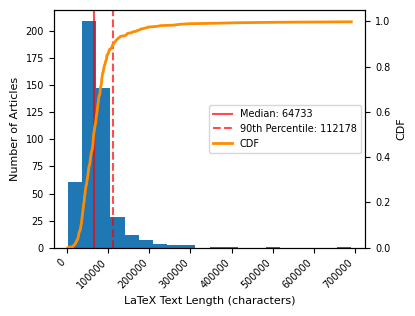

In [29]:

def combined_plot(df):
    sizes = df["tex_size_clean"]
    sorted_sizes = np.sort(sizes)
    cdf = np.arange(len(sorted_sizes)) / len(sorted_sizes)
    
    # 创建图形和主坐标轴
    fig, ax1 = plt.subplots(figsize=(4.2, 3.2))
    
    # 左y轴：直方图
    n, bins, patches = ax1.hist(sizes, bins=20)
    ax1.set_xlabel("LaTeX Text Length (characters)")
    ax1.set_ylabel("Number of Articles")
    ax1.tick_params(axis='y')
    ax1.set_xticks(ax1.get_xticks())
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
    
    # 右y轴：CDF
    ax2 = ax1.twinx()
    ax2.plot(sorted_sizes, cdf, color='darkorange', linewidth=2, label='CDF')
    ax2.set_ylabel("CDF")
    ax2.tick_params(axis='y')
    ax2.set_ylim(0, 1.05)
    
    # 添加中位数和90%分位数
    median = np.median(sizes)
    p90 = np.percentile(sizes, 90)
    
    # 在直方图区域添加竖线
    ax1.axvline(median, linestyle='-', label=f'Median: {median:.0f}', color='red', alpha=0.7)
    ax1.axvline(p90, linestyle='--', label=f'90th Percentile: {p90:.0f}', color='red', alpha=0.7)
    
    # 合并图例
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
    
    plt.tight_layout()
    plt.show()
combined_plot(work_df)